# TQD2026 notebook 4: *Thermofield chain-mapping baths*
## Purified MPS approach for Non-Markovian Open Quantum Systems

This notebook switches back to purified wavefunctions, however now we aim to capture with the MPS not just the system but also a finite portion of a continuous bath. The thermofield transformation purifies the overall state, while the chain-mapping selects a discrete set of modes from the bath optimized to reproduce the real-time dynamics.

<center>
<img src="images/chain_mapping.png" width="400">
</center>

In [1]:
using ITensors
using ITensorMPS
using Plots
using Observers

include("MPS_MPO_helpers.jl")
using .MPS_MPO_helpers

default(; linewidth=2, grid=false, framestyle=:box)

Define parameters for this setup:

In [3]:
T = 15.0; #Total simulation time

left_bath = bath_parameters(Γ = 0.5, β = 10.0, μ = 0.1, D = 1.0, N = 7)
right_bath = bath_parameters(Γ = 0.5, β = 10.0, μ = -0.1, D = 1.0, N = 7)
system = system_parameters(ϵ = [0.0,0.0], t = [0.1], U = [0.0], occupations=["Emp","Emp"]) #Can make the system larger by expanding the parameters lists appropriately

Ns = length(system.ϵ) #Number of system modes
Ns < 2 && error("The system must have at least 2 modes.")

#Define some indices for convenience
L = 2*left_bath.N+2*right_bath.N + length(system.ϵ)
sys_site = 2*left_bath.N+1; #First system mode in the MPS
left_empty = 1:2:2*left_bath.N
left_filled = 2:2:2*left_bath.N
right_empty = 2*left_bath.N+Ns+1:2:2*left_bath.N+Ns+2*right_bath.N
right_filled = 2*left_bath.N+Ns+2:2:2*left_bath.N+Ns+2*right_bath.N;

Define Hamiltonian MPO and initial state MPS:



In [4]:
sites = siteinds("Fermion",L;conserve_qns=true)
H_MPO, H_single, H = build_chain_hamiltonian(sites,left_bath,right_bath,system);

ψ0 = MPS(ComplexF64,sites,thermofield_vacuum(left_bath,right_bath,system));
corr0 = correlation_matrix(ψ0,"Cdag","C");

Plot the density profile in the system to show the initial density of the filled/empty bath chains along with the system site:

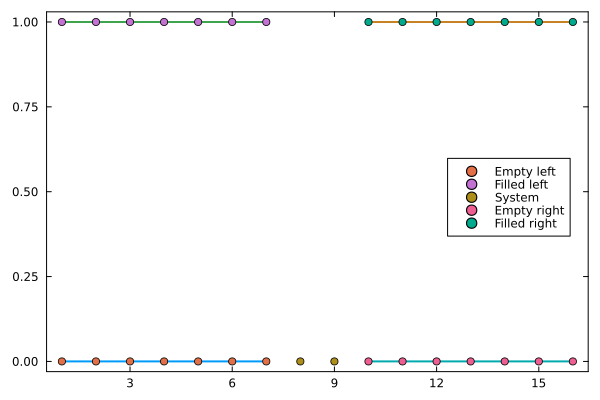

In [5]:
density = real(diag(corr0))
plot(1:left_bath.N,density[left_empty],label="")
scatter!(1:left_bath.N,density[left_empty],label="Empty left",legend=:right)
plot!(1:left_bath.N,density[left_filled],label="")
scatter!(1:left_bath.N,density[left_filled],label="Filled left")
scatter!([left_bath.N.+(1:Ns)], [density[sys_site:(sys_site+Ns)]], label="System")
plot!(left_bath.N.+Ns .+(1:right_bath.N),density[right_empty],label="")
scatter!(left_bath.N.+Ns .+(1:right_bath.N),density[right_empty],label="Empty right")
plot!(left_bath.N.+Ns .+(1:right_bath.N),density[right_filled],label="")
scatter!(left_bath.N.+Ns .+(1:right_bath.N),density[right_filled],label="Filled right")

Compute the exact evolution for the non-interacting case which will serve as our benchmark shortly:

In [6]:
δt = 0.1
corr_exact = propagate_correlations(corr0, H_single, range(δt,stop = T,step = δt)); # Exact evolution of correlation matrix when U = 0

exact_den = real.([corr_exact[sys_site,sys_site] for corr_exact in corr_exact])
exact_currents = real.([im*(system.t[1]*corr_exact[sys_site+1,sys_site] - system.t[1]*corr_exact[sys_site,sys_site+1]) for corr_exact in corr_exact]);

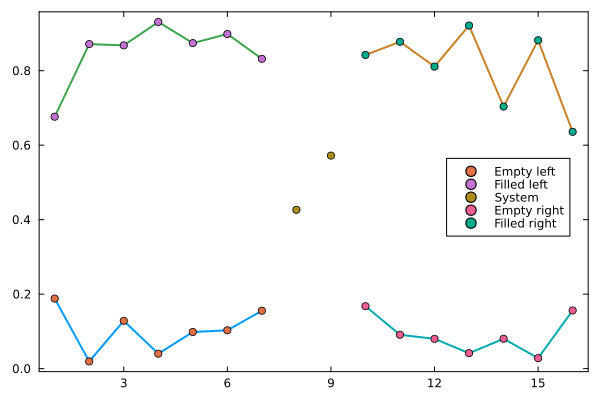

In [14]:
density = real(diag(corr_exact[end]))
plot(1:left_bath.N,density[left_empty],label="")
scatter!(1:left_bath.N,density[left_empty],label="Empty left",legend=:right)
plot!(1:left_bath.N,density[left_filled],label="")
scatter!(1:left_bath.N,density[left_filled],label="Filled left")
scatter!([left_bath.N.+(1:Ns)], [density[sys_site:(sys_site+Ns)]], label="System")
plot!(left_bath.N.+Ns .+(1:right_bath.N),density[right_empty],label="")
scatter!(left_bath.N.+Ns .+(1:right_bath.N),density[right_empty],label="Empty right")
plot!(left_bath.N.+Ns .+(1:right_bath.N),density[right_filled],label="")
scatter!(left_bath.N.+Ns .+(1:right_bath.N),density[right_filled],label="Filled right")

Plot the single-particle correlations at the end from the exact calculation. The interleaved filled and empty modes are evident from the persistent alternating pattern of occupations.

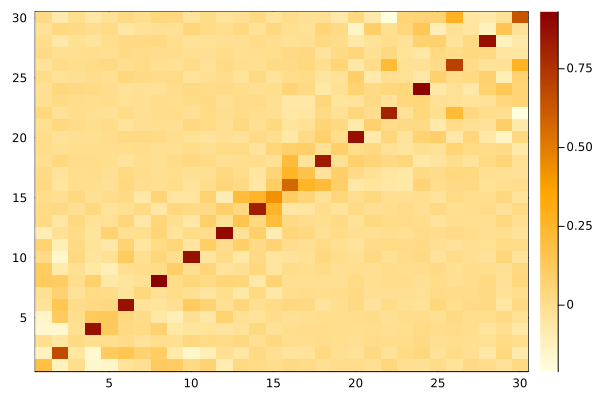

In [7]:
gr()
heatmap(1:L, 1:L, real(corr_exact[end]), c = :heat)

## TDVP evolution

Define current time and the observable function to be called at each time step inside TDVP. This can be modified to capture more observables:

In [8]:
function current_time(; current_time, bond, half_sweep)
    if bond == 1 && half_sweep == 2
    return real(im*current_time)
    end
    return nothing
end

function measure_correlation_matrix(; state, bond, half_sweep)
    if bond==1 && half_sweep == 2
        return correlation_matrix(state,"Cdag","C")
    end
    return nothing
end;

Compute setup parameters and then time-evolve using TDVP:

In [10]:
time_evolution = TDVP_parameters(tdvp_cutoff = 1e-9, minbonddim = 10, maxbonddim = 200, δt = 0.1, total_simulation_time = T)
times_tdvp = range(time_evolution.δt,stop = time_evolution.total_simulation_time,step = time_evolution.δt);

In [11]:
#create observer for TDVP
obs = Observer("times" => current_time, "corr" => measure_correlation_matrix)

ψT = tdvp(H_MPO, -im * time_evolution.total_simulation_time, ψ0; 
    time_step = -im * time_evolution.δt,
    cutoff = time_evolution.tdvp_cutoff, 
    mindim = time_evolution.minbonddim, 
    maxdim = time_evolution.maxbonddim, 
    outputlevel = 1, 
    observer! = obs);

After sweep 1: maxlinkdim=4 maxerr=7.26E-17 current_time=0.0 - 0.1im time=20.816
After sweep 2: maxlinkdim=10 maxerr=6.19E-17 current_time=0.0 - 0.2im time=2.283
After sweep 3: maxlinkdim=10 maxerr=6.01E-19 current_time=0.0 - 0.3im time=2.002
After sweep 4: maxlinkdim=10 maxerr=2.53E-17 current_time=0.0 - 0.4im time=2.065
After sweep 5: maxlinkdim=10 maxerr=2.56E-16 current_time=0.0 - 0.5im time=2.395
After sweep 6: maxlinkdim=10 maxerr=1.34E-15 current_time=0.0 - 0.6im time=2.401
After sweep 7: maxlinkdim=10 maxerr=3.13E-15 current_time=0.0 - 0.7im time=2.36
After sweep 8: maxlinkdim=10 maxerr=7.02E-15 current_time=0.0 - 0.8im time=2.157
After sweep 9: maxlinkdim=10 maxerr=1.44E-14 current_time=0.0 - 0.9im time=2.106
After sweep 10: maxlinkdim=10 maxerr=2.78E-14 current_time=0.0 - 1.0im time=2.08
After sweep 11: maxlinkdim=10 maxerr=5.05E-14 current_time=0.0 - 1.1im time=2.03
After sweep 12: maxlinkdim=10 maxerr=1.01E-13 current_time=0.0 - 1.2im time=2.056
After sweep 13: maxlinkdim=1

Performing plotting and analysis of the results:

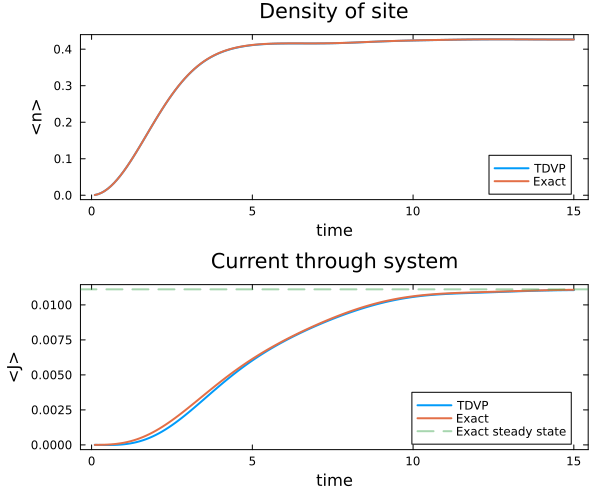

In [12]:
tdvp_den = [corr[sys_site,sys_site] for corr in obs.corr] 
tdvp_currents = real.([im*(system.t[1]*corr[sys_site+1,sys_site] - system.t[1]*corr[sys_site,sys_site+1]) for corr in obs.corr])

p_den = plot(
  times_tdvp,
  real.(tdvp_den),
  xlabel="time",
  ylabel="<n>",
  title="Density of site",
  legend=:bottomright,
  label="TDVP",
)
plot!(p_den, times_tdvp, real.(exact_den), label="Exact")

p_curr = plot(
  times_tdvp,
  tdvp_currents,
  xlabel="time",
  ylabel="<J>",
  title="Current through system",
  legend=:bottomright,
  label="TDVP",
)
plot!(p_curr, times_tdvp, real.(exact_currents), label="Exact")
hline!(p_curr, [LB_current(left_bath,right_bath,system)]; linestyle=:dash, alpha=0.45, label="Exact steady state")

plot(p_den, p_curr; layout=(2, 1), size=(600, 500))

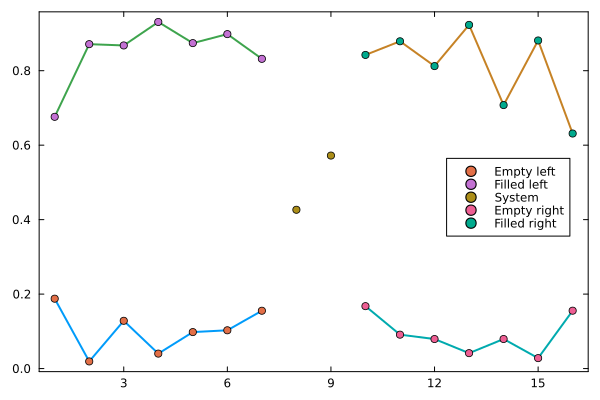

In [13]:
density = real(diag(obs.corr[end]))
plot(1:left_bath.N,density[left_empty],label="")
scatter!(1:left_bath.N,density[left_empty],label="Empty left",legend=:right)
plot!(1:left_bath.N,density[left_filled],label="")
scatter!(1:left_bath.N,density[left_filled],label="Filled left")
scatter!([left_bath.N.+(1:Ns)], [density[sys_site:(sys_site+Ns)]], label="System")
plot!(left_bath.N.+Ns .+(1:right_bath.N),density[right_empty],label="")
scatter!(left_bath.N.+Ns .+(1:right_bath.N),density[right_empty],label="Empty right")
plot!(left_bath.N.+Ns .+(1:right_bath.N),density[right_filled],label="")
scatter!(left_bath.N.+Ns .+(1:right_bath.N),density[right_filled],label="Filled right")

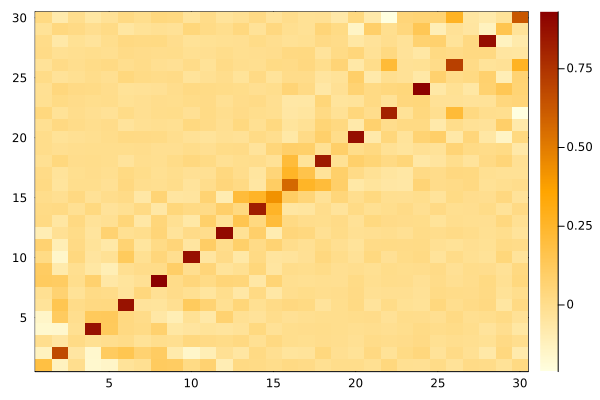

In [15]:
gr()
heatmap(1:L, 1:L, real(obs.corr[end]), c = :heat)

## t-MPS evolution
Now let's use the t-MPS method we used earlier to solve the same problem exploiting our Trotter circuit compiler ability to handle up to 4 contiguous site terms.

In [16]:
δt = 0.05
nsteps = Int(time_evolution.total_simulation_time / δt)
layers = second_order_trotter_circuit(H, sites, δt)
Udt = circuit_mpo(layers, sites; cutoff=1e-10);

In [17]:
times_tmps = Float64[]
entropies = Float64[]
maxlinkdims = Int[]
corr_tmps = Matrix{ComplexF64}[]
entropy_bond::Integer = div(length(ψ0), 2)

psi = deepcopy(ψ0)
for step in 0:nsteps
  push!(times_tmps, step * δt)
  push!(entropies, half_chain_entropy(psi; bond=entropy_bond))
  push!(maxlinkdims, maxlinkdim(psi))
  push!(corr_tmps, correlation_matrix(psi, "Cdag", "C"))
    
  step == nsteps && break
  psi = apply_mpo_step(Udt, psi; cutoff=1e-9, maxdim=200, normalize=false)
end;

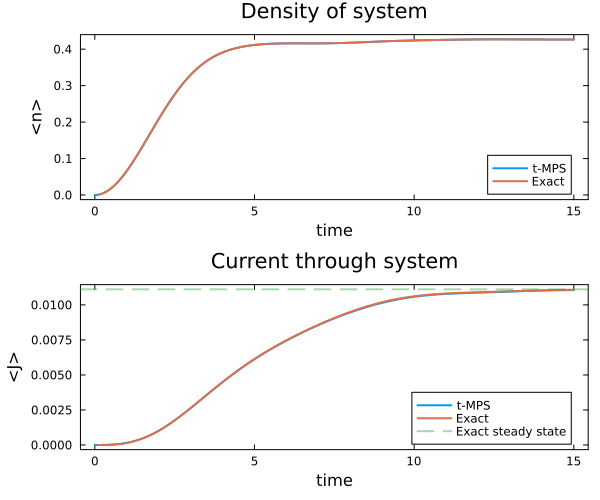

In [18]:
tmps_den = [corr[sys_site,sys_site] for corr in corr_tmps]
tmps_currents = [real.(im*(system.t[1]*corr[sys_site+1,sys_site] - system.t[1]*corr[sys_site,sys_site+1])) for corr in corr_tmps]

p_den_tmps = plot(
  times_tmps,
  real.(tmps_den),
  xlabel="time",
  ylabel="<n>",
  title="Density of system",
  legend=:bottomright,
  label="t-MPS",
)
plot!(p_den_tmps, times_tdvp, real.(exact_den), label="Exact")

p_curr_tmps = plot(
  times_tmps,
  real.(tmps_currents),
  xlabel="time",
  ylabel="<J>",
  title="Current through system",
  legend=:bottomright,
  label="t-MPS",
)
plot!(p_curr_tmps, times_tdvp, real.(exact_currents), label="Exact")
hline!(p_curr_tmps, [LB_current(left_bath,right_bath,system)]; linestyle=:dash, alpha=0.45, label="Exact steady state")

plot(p_den_tmps, p_curr_tmps; layout=(2, 1), size=(600, 500))

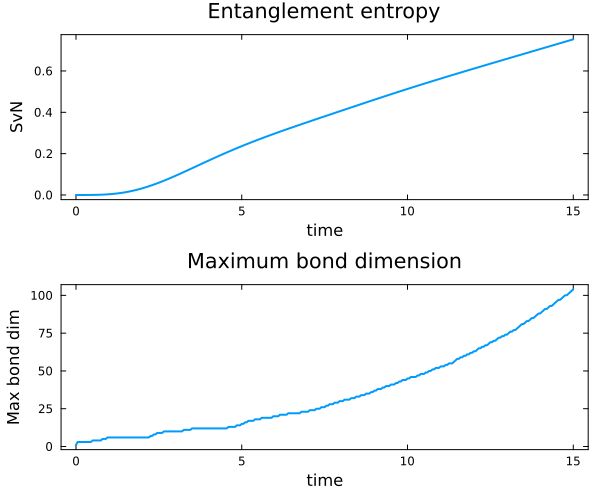

In [19]:
p_ent = plot(
  times_tmps,
  entropies,
  xlabel="time",
  ylabel="SvN",
  title="Entanglement entropy",
  label="",
)

p_bond = plot(
  times_tmps,
  maxlinkdims,
  xlabel="time",
  ylabel="Max bond dim",
  title="Maximum bond dimension",
  label="",
)

plot(p_ent, p_bond; layout=(2, 1), size=(600, 500))

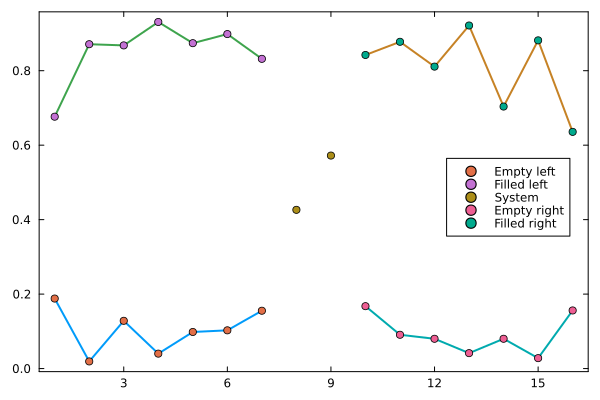

In [20]:
density = real(diag(corr_tmps[end]))
plot(1:left_bath.N,density[left_empty],label="")
scatter!(1:left_bath.N,density[left_empty],label="Empty left",legend=:right)
plot!(1:left_bath.N,density[left_filled],label="")
scatter!(1:left_bath.N,density[left_filled],label="Filled left")
scatter!([left_bath.N.+(1:Ns)], [density[sys_site:(sys_site+Ns)]], label="System")
plot!(left_bath.N.+Ns .+(1:right_bath.N),density[right_empty],label="")
scatter!(left_bath.N.+Ns .+(1:right_bath.N),density[right_empty],label="Empty right")
plot!(left_bath.N.+Ns .+(1:right_bath.N),density[right_filled],label="")
scatter!(left_bath.N.+Ns .+(1:right_bath.N),density[right_filled],label="Filled right")

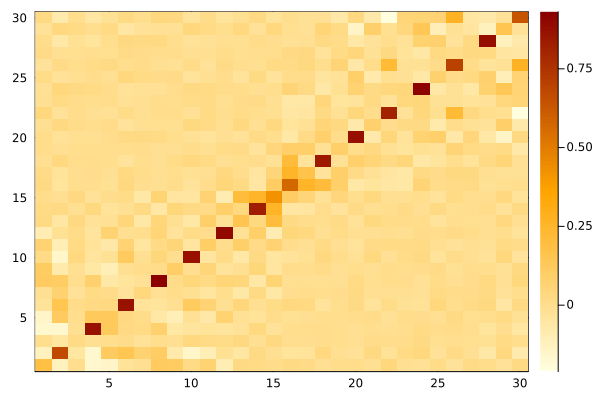

In [21]:
gr()
heatmap(1:L, 1:L, real(corr_tmps[end]), c = :heat)

For this example we see that t-MPS is competitive with TDVP. However, TDVP is much more flexible and can in principle handle Hamiltonians with much longer-ranged couplings.